# What drives the US yield curve?

The US Treasury curve is 8 numbers a day. Over 25 years that's about 6,600 days times 8
maturities. This notebook shows that almost all of that movement comes down to three
numbers, and then uses those three numbers to read back 25 years of Fed policy.

Litterman and Scheinkman found this three-factor structure in 1991. I rebuilt their result
from scratch on data they never saw, and then asked two things they couldn't: what do the
factors say about each Fed cycle since 2000, and does the structure hold up in a crisis?

One of my six predictions was wrong, and the main hypothesis I started with turned out to
be false. Both are written up below.

Data: FRED daily constant-maturity yields, 2000-01-03 to 2026-07-23, 6,642 trading days.

In [2]:
import os, sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import config, plots, events, hedging, resampling, queries
from src.pca_engine import first_diff, fit_pca, adf_table, rmse_table, sklearn_crosscheck
from src.rolling import rolling_pca

show = lambda p: Image(filename=str(p))

# With a FRED key this pulls real data. Without one it falls back to generated
# data and says so, so I can't quote fake numbers by mistake.
SYNTHETIC = os.environ.get("FRED_API_KEY") is None and not config.DB_PATH.exists()

if SYNTHETIC:
    from src.synthetic import make_synthetic
    levels, usrec = make_synthetic()
    print("SYNTHETIC DATA - generated, not real. Numbers below are meaningless.")
else:
    from src import etl
    if not config.DB_PATH.exists():
        etl.run_etl()
    levels, usrec = etl.load_clean()
    print("Real FRED data.")

print(f"{levels.index[0].date()} to {levels.index[-1].date()}, "
      f"{len(levels)} days, {levels.shape[1]} maturities")
levels.tail(3)

Real FRED data.
2000-01-03 to 2026-07-23, 6642 days, 8 maturities


,m3,m6,y1,y2,y3,y5,y7,y10
date,,,,,,,,
2026-07-21,3.87,4.02,4.08,4.26,4.31,4.37,4.50,4.63
2026-07-22,3.89,4.05,4.11,4.31,4.34,4.41,4.53,4.67
2026-07-23,3.95,4.09,4.15,4.37,4.40,4.46,4.58,4.71


## The data

Eight maturities: 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y.

I left out the 1-month and the 30-year. The 1-month only starts in mid-2001 and is noisy
for reasons that have nothing to do with the term structure (money-market technicals, debt
ceiling episodes). The 30-year has a bigger problem: Treasury stopped issuing it from 2002
to 2006, so the series has a four-year hole. If I had kept it, the inner join would have
quietly deleted four years from every other maturity too.

For missing days I drop rather than fill. FRED marks market holidays as missing. Filling
them would add about 287 days where every yield "changed" by exactly zero, which is 4% of
the sample and pure noise reduction that isn't real. Dropping costs 4.1% of days.

I ran it both ways out of curiosity and the explained-variance numbers came out identical
to one decimal place. That makes sense once you think about it: 287 rows of all-zeros just
rescale the covariance matrix by a constant, and scaling doesn't rotate eigenvectors. Free
robustness check.

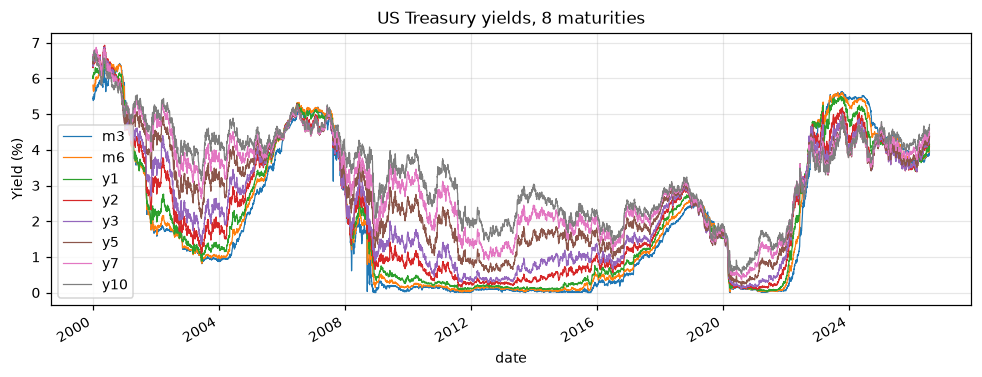

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
levels.plot(ax=ax, lw=0.8)
ax.set(title="US Treasury yields, 8 maturities", ylabel="Yield (%)")
config.FIG_DIR.mkdir(exist_ok=True)
fig.tight_layout(); fig.savefig(config.FIG_DIR / "nb_01_levels.png", bbox_inches="tight")
plt.close(fig)
show(config.FIG_DIR / "nb_01_levels.png")

## Why I work with daily changes, not levels

Yield levels behave close to a random walk. If I run PCA on levels, the first component
just picks up the 25-year downtrend and the 2022 reversal. That's a trend, not the
co-movement structure I'm after.

Taking first differences fixes it. The ADF test confirms both halves of the argument:
levels fail to reject a unit root (p between 0.11 and 0.30, all 8 maturities), and the
differences reject it strongly (p below 0.001, all 8).

In [4]:
adf = adf_table(levels)
display(adf)
print(f"levels non-stationary: {(adf['p_level'] > 0.10).sum()}/8")
print(f"changes stationary:    {(adf['p_diff'] < 0.01).sum()}/8")

,p_level,p_diff
m3,0.2959,0.0
m6,0.2763,0.0
y1,0.2744,0.0
y2,0.1612,0.0
y3,0.2185,0.0
y5,0.1511,0.0
y7,0.1125,0.0
y10,0.1147,0.0


levels non-stationary: 8/8
changes stationary:    8/8


## The three factors

I run PCA two ways and use each for a different purpose.

The correlation version z-scores each maturity first, so every maturity counts equally.
That's the cleaner view of the structure and it's what the plots use. The covariance
version only centres, so the loadings stay in basis points. I need that for the event
study and the hedging section, where "how many bps" is the whole point.

These are genuinely two different problems (eigenvectors of the correlation matrix versus
the covariance matrix), not one problem with a preprocessing switch. Both give the same
three shapes, which is itself a sign the result is robust.

Result: 71.8% / 18.3% / 5.1%, so 95.2% for three factors. On the covariance basis it's
78.2 / 13.3 / 4.6, or 96.1%. Effective rank is 2.47, meaning the bond market behaves like
a 2.5-dimensional system rather than an 8-dimensional one.

I wrote the eigendecomposition myself rather than calling sklearn, then checked against
sklearn. They agree to 0.00e+00.

In [5]:
changes = first_diff(levels)
res_corr = fit_pca(changes, mode="corr")
res_cov  = fit_pca(changes, mode="cov")

print(f"correlation basis: {np.round(res_corr.evr[:4]*100, 1)}%  top-3 = {res_corr.evr[:3].sum():.1%}")
print(f"covariance basis:  {np.round(res_cov.evr[:4]*100, 1)}%  top-3 = {res_cov.evr[:3].sum():.1%}")
print(f"effective rank:    {res_corr.effective_rank:.2f}")
print(f"vs sklearn:        {sklearn_crosscheck(changes, res_corr):.2e}")

correlation basis: [71.8 18.3  5.1  2.4]%  top-3 = 95.2%
covariance basis:  [78.2 13.3  4.6  1.8]%  top-3 = 96.1%
effective rank:    2.47
vs sklearn:        0.00e+00


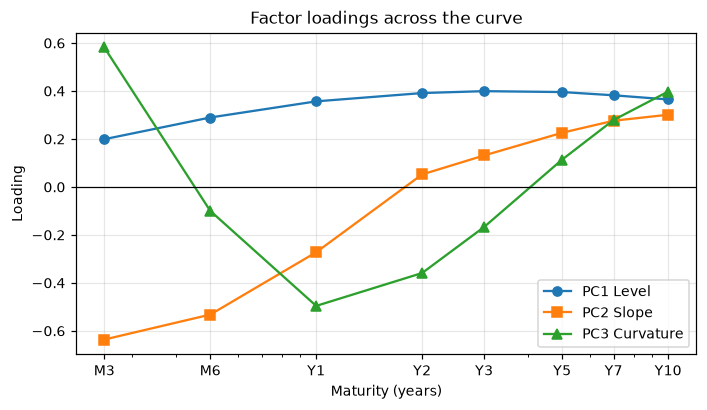

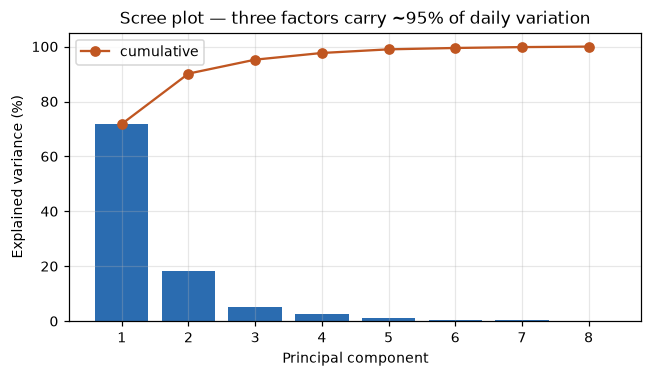

In [6]:
display(show(plots.loadings(res_corr.eigenvectors)))
display(show(plots.scree(res_corr.evr)))

### Are they actually what I think they are?

The loadings have the right shapes, but shape alone doesn't prove the first factor is
"level" and the second is "slope". So I check them against two quantities computed
straight from the raw data, with no PCA involved.

If PC1 is really a level factor it should track the average daily change across all eight
maturities. If PC2 is really slope, its cumulative sum should track the 10Y minus 2Y
spread. I get 0.999 and 0.897.

In [7]:
c1 = np.corrcoef(res_corr.scores["PC1"], changes.mean(axis=1))[0, 1]
spread = (levels["y10"] - levels["y2"]).reindex(res_corr.scores.index)
c2 = np.corrcoef(res_corr.scores["PC2"].cumsum(), spread)[0, 1]
print(f"corr(PC1, average change)      = {c1:+.3f}")
print(f"corr(cumulative PC2, 10Y-2Y)   = {c2:+.3f}")

corr(PC1, average change)      = +0.999
corr(cumulative PC2, 10Y-2Y)   = +0.897


Reconstruction error puts a number on the compression. Rebuilding the daily changes from
just three factors leaves about 1 bp per day of error at every maturity.

In [8]:
display(rmse_table(changes, res_corr))

,k=1,k=2,k=3
m3,3.96,1.90,0.91
m6,2.71,1.20,1.18
y1,2.16,1.66,1.01
y2,1.88,1.85,1.37
y3,1.66,1.38,1.24
y5,1.92,0.96,0.85
y7,2.44,1.34,0.79
y10,2.80,1.84,1.12


## Reading 25 years of Fed policy through the factors

For each episode I take the total curve move from start to end and project it onto the
three factors. The covariance basis is used here so the contributions come out in bps.

Two things to keep this honest. The start and end dates come from documented events (FOMC
decisions, the Bernanke testimony, the unlimited-QE announcement) and are written into
`src/config.py` before I look at any output. And I report the residual for every episode,
so if three factors don't span the move, it shows.

Here's what I expected before running it:

| Episode | Expected |
|---|---|
| 2004-06 hikes | Bear flattening, PC2 dominant |
| 2007-08 GFC | Bull steepening plus a level collapse |
| 2013 taper tantrum | Bear steepening, long end leading |
| 2020 COVID | Level collapse, close to one-dimensional |
| 2022-23 inflation fight | Textbook bear flattening |
| 2024- easing | Bull steepening |

Sign convention: positive PC2 means the curve steepened.

,t0,t1,PC1_bps,PC2_bps,PC3_bps,residual_share
episode,,,,,,
2004-06 Fed hikes ('Greenspan's conundrum'),2004-06-30,2006-06-29,497.7,-498.2,-29.6,0.059
2007-08 GFC easing to zero,2007-09-18,2008-12-16,-799.2,451.0,-17.3,0.049
2013 Taper tantrum,2013-05-22,2013-09-05,161.7,65.7,45.1,0.084
2020 COVID crash to zero,2020-02-19,2020-03-23,-285.0,174.5,-18.5,0.057
2022-23 inflation fight (deepest inversion since 1981),2022-03-16,2023-07-26,687.5,-621.7,64.3,0.094
2024- easing cycle / dis-inversion,2024-09-18,2026-07-23,184.2,135.6,-40.0,0.053


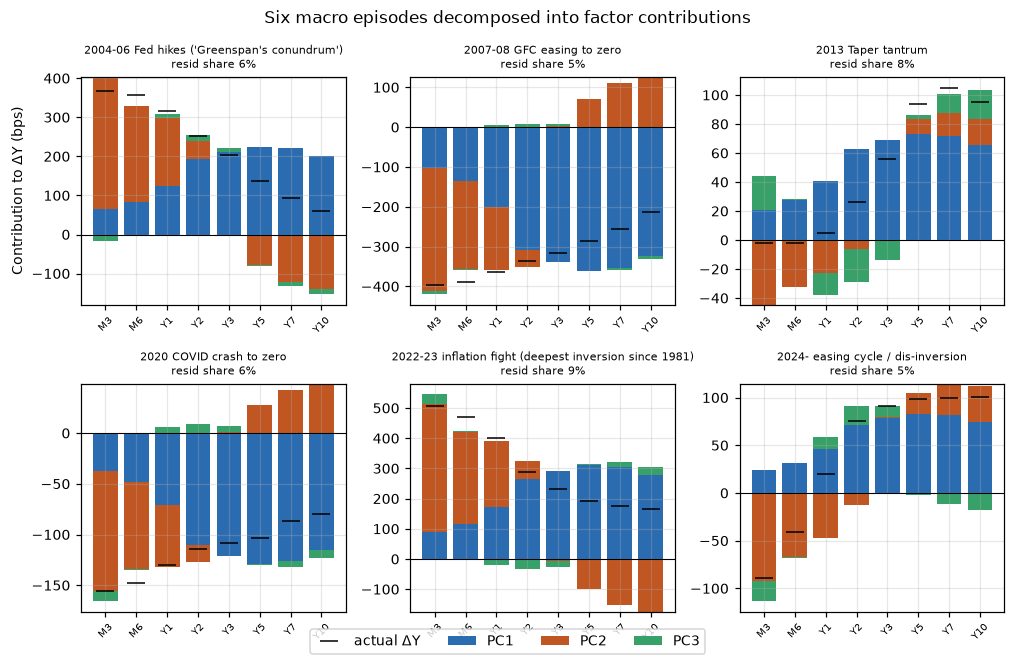

In [9]:
study = events.run_event_study(levels, res_cov.eigenvectors)
display(events.summary_table(study))
display(show(plots.episode_bars(study)))

### What actually happened

Residuals stay under 10% everywhere, so three factors do span these moves.

**2004-06, Greenspan's conundrum.** PC1 came in at +497.7 bps and PC2 at -498.2. Those
almost exactly cancel. That's the conundrum in one line: the Fed took rates from 1% to
5.25%, the whole curve should have lifted by roughly 500 bps, but the flattening took back
the same amount at the long end, so the 10-year barely moved. Curvature was only -29.6, so
the curve rotated cleanly around a pivot.

**2007-08.** PC1 at -799.2, the largest level move in the sample. PC2 at +451 as the Fed
cut from 5.25% to zero and the front end fell faster than the back. Residual was 4.9%, the
lowest of the six. A full-blown crisis turned out to be the most structured move here.

**2013 taper tantrum.** PC1 +161.7 and PC2 +65.7, so bear steepening as expected. What I
didn't expect was PC3 at +45.1, the largest curvature share of any episode. It fits though.
QE was aimed at the long end, so when Bernanke only hinted at tapering, the repricing hit
the middle and back of the curve unevenly. That's a real twist, not just a shift or a
rotation.

**2020 COVID.** PC1 -285 in five weeks. But my "close to one-dimensional" guess was wrong:
PC2 came in at +174.5, about 61% the size of PC1. The curve didn't just collapse, it
steepened hard at the same time. This is the first hint of what I find in the next section.

**2022-23.** PC1 +687.5, PC2 -621.7. Textbook bear flattening and the largest total move in
the sample. The Fed went up 525 bps faster than at any time since Volcker and the curve
stayed inverted for 537 straight trading days, which the SQL section confirms is the record.

**2024 onwards, and this is the one I got wrong.** I predicted bull steepening: the Fed
cuts, so rates fall. What I got was PC1 at +184.2, meaning the overall level went *up*,
together with PC2 at +135.6. That's bear steepening.

The reason is that I quietly assumed the Fed cutting the front end pulls the whole curve
down with it. It doesn't. The Fed cut short rates from September 2024, but the long end
sold off harder on term premium, sticky inflation and supply concerns. So the curve escaped
its inversion by the long end climbing, not the short end falling. The Fed sets the front
end and only influences the back end, and this episode is the cleanest illustration of that
in the whole 25 years.

## Does the structure hold still?

Running PCA once on 25 years assumes the covariance structure is constant the whole time.
That's worth testing, so I rerun it on a 252-day rolling window, stepping a month at a time.

Each window is standardised using only its own data. Standardising on the full sample first
would let a 2003 window borrow information from 2020, which is leakage.

There's one technical wrinkle here that took a while to get right. Eigenvectors are only
defined up to sign, and when two eigenvalues are close, the algorithm can hand back PC2 and
PC3 in swapped order. Left alone, the loading series jump around and the plots are useless.
I align each window against the previous one by dot product, flipping signs and swapping the
2/3 pair where needed.

In the end it swapped zero times across 305 windows, because 18.3% versus 5.1% is a wide
enough gap that the two never get confused. The sign fixing did matter. Worth being honest
about: the alignment code is insurance that never had to pay out on this dataset.

305 windows, PC2/PC3 swaps: 0
PC1 share: median 72.7%, max 82.7% on 2002-01-09
effective rank: median 2.45, min 1.90


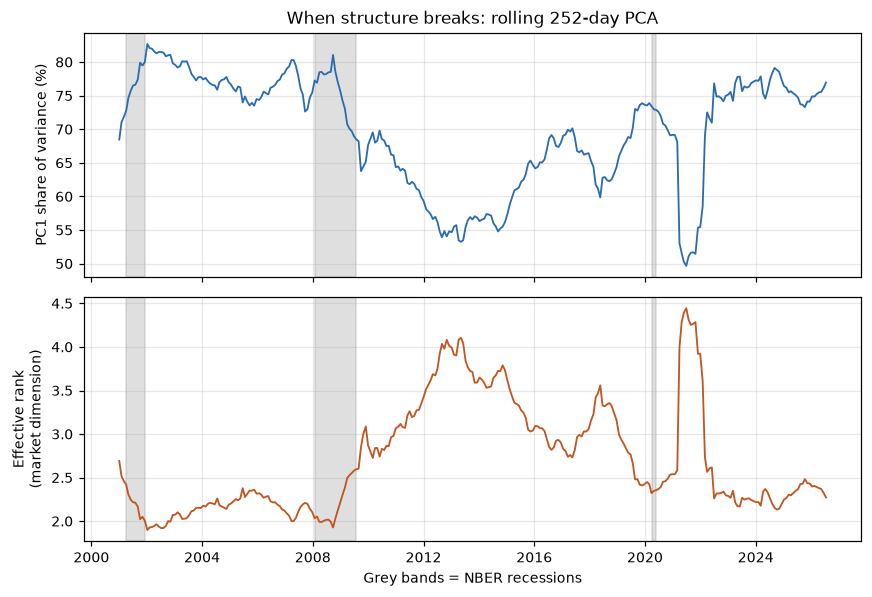

In [10]:
summary, roll_loadings = rolling_pca(changes)
print(f"{len(summary)} windows, PC2/PC3 swaps: {summary.attrs['n_swaps']}")
print(f"PC1 share: median {summary['evr1'].median():.1%}, "
      f"max {summary['evr1'].max():.1%} on {summary['evr1'].idxmax().date()}")
print(f"effective rank: median {summary['erank'].median():.2f}, min {summary['erank'].min():.2f}")
display(show(plots.rolling_evr(summary, usrec)))

The loadings below are the evidence that the alignment works. Without it these lines would
flip and cross randomly between windows. They're smooth and keep their order for 25 years.

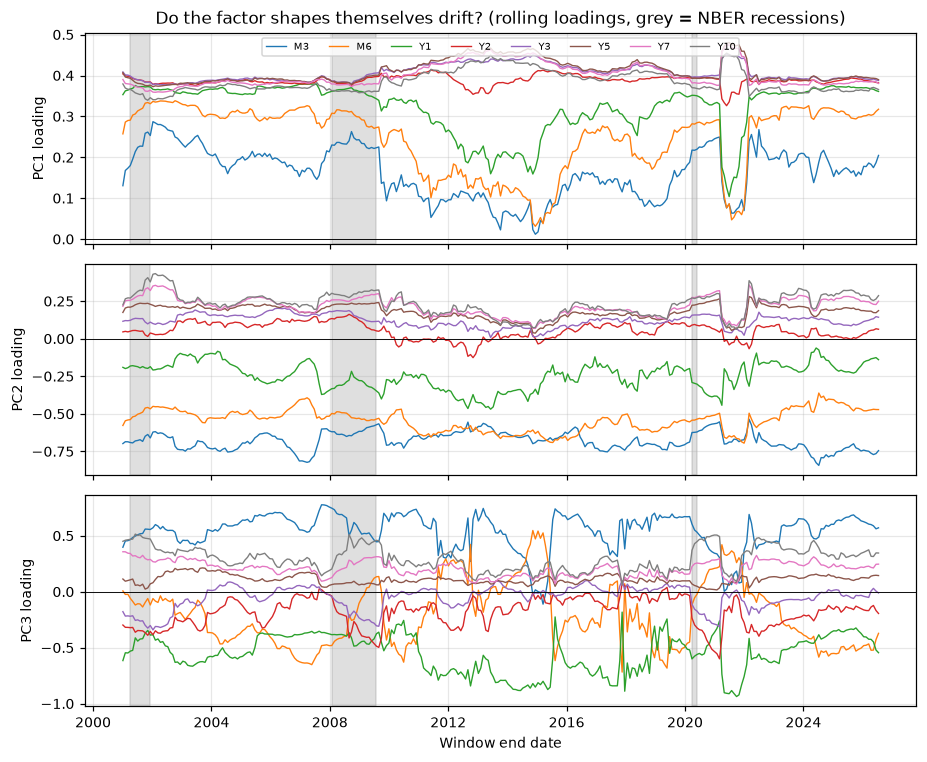

In [11]:
display(show(plots.rolling_loadings(roll_loadings, usrec)))

### Testing the hypothesis I started with

My original guess was that crises squeeze the curve toward one dimension. Everything gets
sold at once, correlations go to one, so PC1 should spike above 90%.

That intuition comes from cross-asset risk, where it's well documented. I wanted to check
whether it holds inside the Treasury curve, so I compared crisis windows against the rest
of the sample. I test both bases, because the correlation version z-scores inside each
window and therefore removes exactly the volatility blow-up the hypothesis is about.

In [12]:
crises = {"GFC 2008": ("2008-06-01", "2009-06-30"),
          "COVID 2020": ("2020-02-01", "2020-12-31"),
          "Hikes 2022": ("2022-03-01", "2023-07-31")}

for mode in ("corr", "cov"):
    s = summary if mode == "corr" else rolling_pca(changes, mode="cov")[0]
    mask = np.zeros(len(s), dtype=bool)
    for a, b in crises.values():
        mask |= (s.index >= a) & (s.index <= b)
    print(f"[{mode}] outside crises {s.loc[~mask,'evr1'].median():.1%} | "
          f"in crises {s.loc[mask,'evr1'].median():.1%} | max {s.loc[mask,'evr1'].max():.1%}")

[corr] outside crises 70.0% | in crises 74.2% | max 81.1%
[cov] outside crises 86.9% | in crises 79.5% | max 85.7%


### The hypothesis was wrong

| Basis | Outside crises | In crises |
|---|---|---|
| Correlation | 70.0% | 74.2% |
| Covariance | 86.9% | 79.5% |

No spike above 90% anywhere. The highest PC1 share in the whole sample is 82.7%, and it
lands in January 2002, not 2008 or 2020.

The two bases move in opposite directions, and that's the answer. Once volatility is
normalised away, correlations do tighten a little in crises, 70% to 74%. But measured in
actual basis points the curve becomes *more* multi-dimensional, 87% down to 80%.

The reason is in the event study above. The dominant thing that happens in a bond crisis
isn't every maturity falling together. It's the Fed slamming the front end to zero while
the long end sits still, which is a huge slope move. GFC had PC2 at +451 bps, COVID at
+174.5. That extra variance is orthogonal to level, so it pushes PC1's share down.

So the honest conclusion is the opposite of what I set out to show. Crises don't compress
the curve, they rotate it violently. The three-factor structure itself is remarkably stable:
PC1 stays in a 70-83% band for 25 years and effective rank only drops from 2.45 to 1.90 at
its most extreme.

One caveat. Consecutive windows share 231 of their 252 days, so these numbers are heavily
autocorrelated and shouldn't be read as independent observations. This is descriptive
evidence, not a significance test.

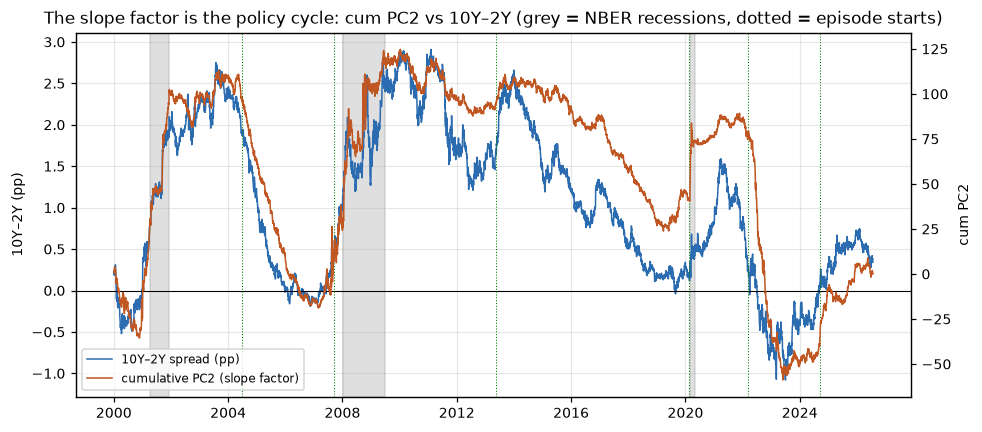

In [13]:
display(show(plots.hero_timeline(res_corr.scores, levels, usrec, study)))

## Why any of this matters: hedging

Standard duration hedging assumes the curve moves in parallel, which is another way of
saying it assumes only PC1 exists. PC2 and PC3 are 23.4% of the variation, so that
assumption should cost something. Here's how much.

I take a long position in 10-year Treasuries and hedge it two ways. The duration hedge
offsets in 2-year notes so total dollar duration is zero. The PC hedge uses two instruments
and solves for the sizes that make the position orthogonal to both PC1 and PC2.

Long $100mm Y10                                      exposure to PC1/PC2/PC3: [34329. 23785. 37446.]
Long $100mm Y10 + duration-hedge @ Y2                exposure to PC1/PC2/PC3: [ 1496. 31975. 79608.]
Long $100mm Y10 + PC-hedge @ Y2/Y5                   exposure to PC1/PC2/PC3: [   0.    0. 5617.]


,Long $100mm Y10,Long $100mm Y10 + duration-hedge @ Y2,Long $100mm Y10 + PC-hedge @ Y2/Y5
hiking_2004,-5100000,16235000,-1551734
gfc_2008,18105000,-10370000,1011395
taper_2013,-8075000,-5865000,1835347
covid_2020,6800000,-2890000,264795
inflation_2022,-14195000,10200000,-5899271
easing_2024,-8585000,-2125000,-605917


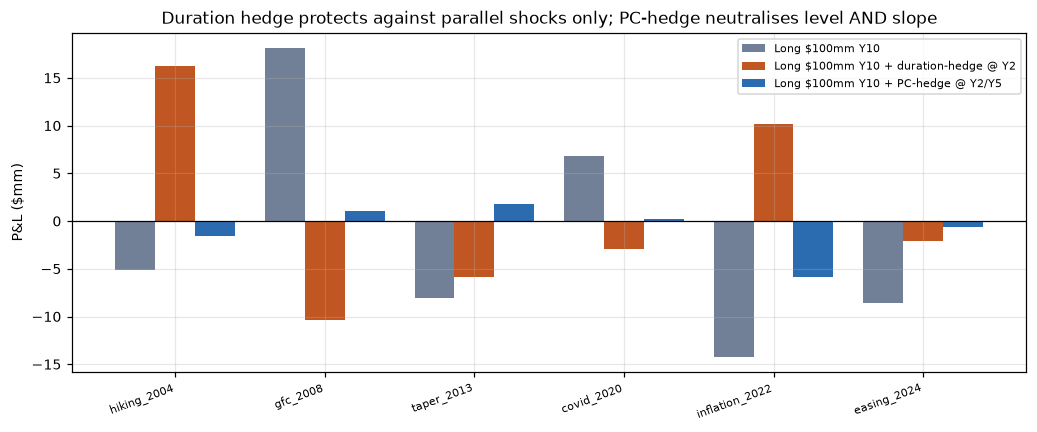

In [14]:
base = hedging.long_position("y10", notional=100e6)
dur  = hedging.duration_hedge(base, hedge_tenor="y2")
pch  = hedging.pc_hedge(base, res_cov.eigenvectors, hedge_tenors=("y2", "y5"))

for p in (base, dur, pch):
    print(f"{p.label:52s} exposure to PC1/PC2/PC3: {np.round(p.exposure(res_cov.eigenvectors, 3), 0)}")

pnl = hedging.pnl_table([base, dur, pch], {k: d["delta"] for k, d in study.items()})
display(pnl)
display(show(plots.hedging_comparison(pnl)))

The duration hedge does what it says: PC1 exposure drops from 34,329 to 1,496. But PC2
exposure goes *up*, from 23,785 to 31,975, and PC3 more than doubles, from 37,446 to 79,608.
The hedging instrument carries its own slope and curvature loadings, so I removed one
dimension of risk by importing two more.

In P&L terms the duration hedge makes things worse in four of the six episodes. In 2004-06
it turns a $5.1m loss into a $16.2m gain, which sounds good until you notice that a hedge
producing that kind of number has stopped being a hedge and become a large directional bet.

The PC hedge zeroes PC1 and PC2 exactly and keeps P&L small and consistent. It still leaves
5,617 of curvature exposure. Neutralising PC3 as well would need a third instrument.

## Appendix

Four shorter checks. Full detail is in `src/` and the code guide.

### Is 71.8% actually meaningful?

A permutation test answers this. Shuffling each maturity's time order separately destroys
the cross-maturity correlation while leaving each series' own distribution untouched, which
gives a fair "what if these were unrelated" benchmark. The null sits at 13.1%, close to the
1/8 = 12.5% you'd expect from noise. The observed 71.8% falls completely outside it.

A block bootstrap gives the precision. Blocks of 21 days rather than single days, because
daily changes are autocorrelated and resampling day by day would give a falsely narrow
interval.

In [15]:
perm = resampling.permutation_test(changes, n_perm=500, seed=0)
boot = resampling.block_bootstrap_evr1(changes, n_boot=500, seed=0)
print(f"observed EVR1 {perm.observed_evr1:.1%}")
print(f"null: mean {perm.null_mean:.1%}, max {perm.null_evr1.max():.1%}, p = {perm.p_value:.4f}")
print(f"95% CI: [{boot.ci_lo:.1%}, {boot.ci_hi:.1%}], block = {boot.block_length}d")

observed EVR1 71.8%
null: mean 13.1%, max 13.5%, p = 0.0020
95% CI: [70.4%, 73.3%], block = 21d


### Do the factors drift over time?

Splitting the sample into three equal periods and measuring the angle between each period's
factors and the full-sample ones.

In [16]:
from src.sensitivity import subperiod_stability
evr, angles = subperiod_stability(levels)
display(evr); display(angles)

,n_days,EVR1,EVR2,EVR3,cum_top3
period,,,,,
P1: 2000-01-04→2008-11-06,2214,0.7546,0.1751,0.0349,0.9646
P2: 2008-11-07→2017-09-13,2214,0.6334,0.1821,0.0772,0.8926
P3: 2017-09-14→2026-07-23,2213,0.7371,0.1563,0.0579,0.9513


,angle_PC1_deg,angle_PC2_deg,angle_PC3_deg
period,,,
P1: 2000-01-04→2008-11-06,1.23,3.48,9.29
P2: 2008-11-07→2017-09-13,7.57,8.74,20.73
P3: 2017-09-14→2026-07-23,0.70,4.68,9.10


The middle period stands out. From late 2008 to 2017, PC1 explains only 63.3% instead of the
usual 73-75%, three factors get to 89.3% instead of 95%, and the curvature factor sits 20.7
degrees away from the full-sample one.

That's the zero-rate era, and the reason is straightforward. With the front end pinned at
zero for years, the short maturities essentially stopped moving, and a correlation structure
built on everything moving together doesn't survive that.

So the answer to "when does the structure break" isn't crises after all. It's a policy
regime that freezes one end of the curve for long enough. Worth noting this also explains
why the empirical PC1 tilts toward longer maturities, which shows up again in the next check.

I also checked the tenor set and the window length. Dropping the 3M and 6M pushes PC1 from
71.8% to 86.3%, so the short end is what makes the curve multi-dimensional in the first
place. Window lengths of 126, 252 and 504 days all give the same picture.

### A second opinion: Nelson-Siegel

PCA finds the three factors statistically, letting the data pick the shapes. Nelson-Siegel
assumes the shapes up front (a flat one, a decaying one, a humped one) and fits three
coefficients per day by least squares. The two methods have nothing in common mechanically,
so if they land on the same factors that's decent evidence the structure is real rather
than an artefact of either method.

NS fit error: 6.2 bps/day


,PC1,PC2,PC3
Δ NS level,0.672,0.342,0.606
Δ NS slope,-0.456,-0.832,-0.285
Δ NS curv,0.437,0.263,-0.790


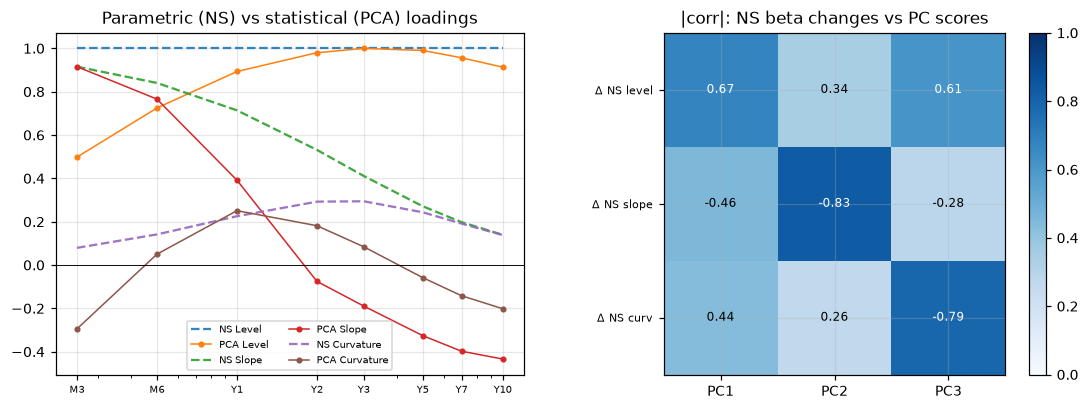

In [17]:
from src import nelson_siegel as ns
ns_res = ns.fit_nelson_siegel(levels)
corr = ns.factor_correlation(ns_res, res_corr.scores)
print(f"NS fit error: {ns_res.rmse_bps:.1f} bps/day")
display(corr.round(3))
display(show(plots.ns_pca_comparison(ns.ns_loadings(), res_corr.eigenvectors, corr)))

Slope matches at 0.832 and curvature at 0.790, both solid. Level only reaches 0.672, and it
also correlates 0.606 with PC3, so it doesn't discriminate well.

That's not a bug, it's the functional form being slightly wrong for this data. Nelson-Siegel
forces the level loading to be flat at 1 across all maturities. The empirical PC1 isn't flat:
on the covariance basis it loads 0.130 at 3M and rises with maturity. Same cause as the
zero-rate finding above.

### SQL

The database isn't just storage. These run inside SQLite with window functions and
conditional aggregation.

In [18]:
if not SYNTHETIC and config.DB_PATH.exists():
    display(queries.yearly_summary().tail(6))
    display(queries.longest_inversion_streaks())
    display(queries.regime_day_counts())
else:
    print("needs the real database")

,year,avg_10y,avg_2y,avg_10y_2y_spread,min_spread,inverted_days,trading_days,pct_inverted
21,2021,1.447,0.265,1.181,0.72,0,251,0.0
22,2022,2.951,2.986,-0.036,-0.84,125,249,50.2
23,2023,3.959,4.583,-0.624,-1.08,250,250,100.0
24,2024,4.208,4.372,-0.164,-0.47,166,250,66.4
25,2025,4.293,3.811,0.482,0.20,0,249,0.0
26,2026,4.341,3.825,0.516,0.27,0,140,0.0


,start_date,end_date,trading_days_inverted
0,2022-07-06 00:00:00,2024-08-26 00:00:00,537
1,2000-02-11 00:00:00,2000-12-26 00:00:00,220
2,2006-08-17 00:00:00,2007-03-20 00:00:00,147
3,2006-01-31 00:00:00,2006-03-07 00:00:00,25
4,2006-06-30 00:00:00,2006-07-26 00:00:00,18


,regime,n_days
0,bear_steepening,1933
1,bull_flattening,1841
2,bull_steepening,1273
3,bear_flattening,1238
4,flat_day,356


## Limits

PCA describes what happened. It has no dynamics and no no-arbitrage constraint, so it can't
price anything. Getting to pricing means affine models under the risk-neutral measure
(Vasicek, CIR), which is where I want to take this next.

The rolling results are descriptive. Overlapping windows make them autocorrelated, so they
aren't a significance test.

The factors drift. Up to 20.7 degrees in the zero-rate period, so "constant structure" is
only approximately true, and it's least true exactly when things were most unusual.

On the data: DGS series are par yields, not zero-coupon. Fine for looking at factor shapes,
but any pricing work would need a fitted zero curve such as the Fed's GSW dataset.

### References

- Litterman, R. & Scheinkman, J. (1991). Common Factors Affecting Bond Returns. *Journal of Fixed Income*.
- Diebold, F.X. & Li, C. (2006). Forecasting the Term Structure of Government Bond Yields. *Journal of Econometrics*.
- Lord, R. & Pelsser, A. (2007). Level-Slope-Curvature: Fact or Artefact? *Applied Mathematical Finance*.